In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [53]:
titanic=sns.load_dataset("titanic")
titanic.info()
titanic.isnull().sum()
titanic.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [17]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [39]:
# imputer  
from sklearn.impute import SimpleImputer
imp_median = SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [45]:
#enocing
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [55]:
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [57]:
X=titanic[features]
y=titanic[target]

In [59]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [65]:
#Training a model 
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()

model.fit(X_train,y_train)

DecisionTreeClassifier()

In [83]:
from sklearn.metrics import accuracy_score

y_pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7877094972067039


In [92]:
from sklearn.tree import plot_tree

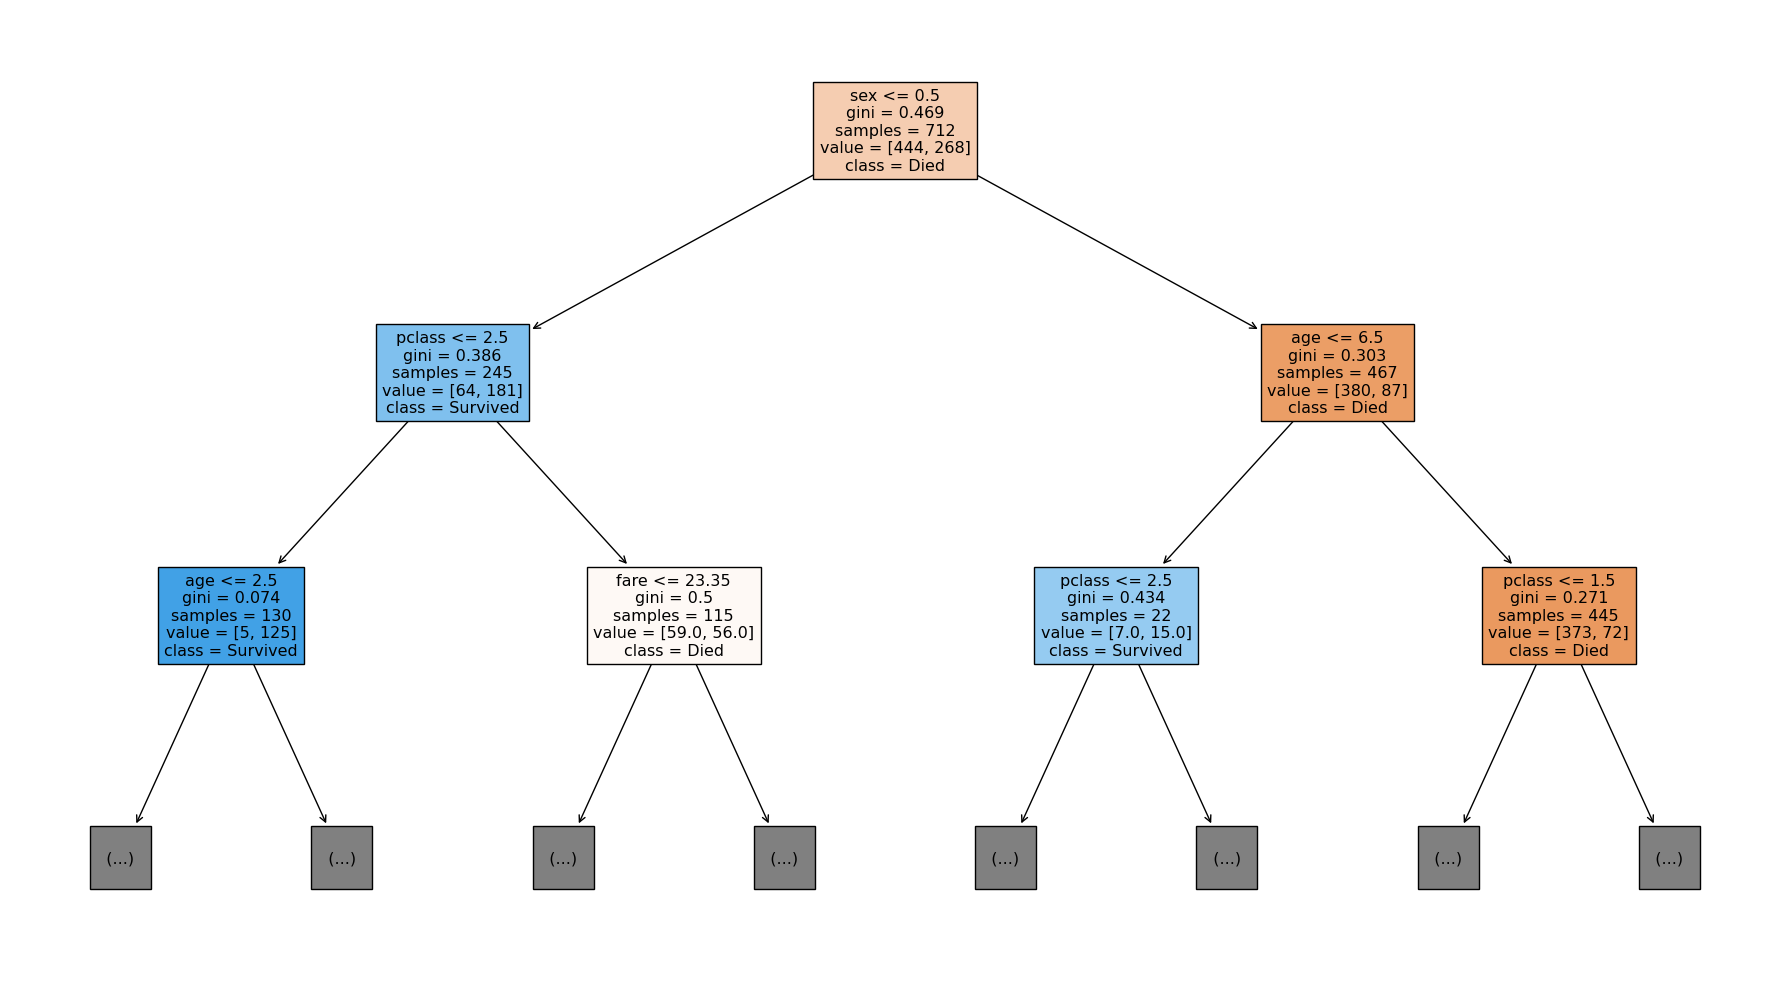

In [106]:

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

# pre-pruning

for depth=2, accuracy=0.7653631284916201
for depth=3, accuracy=0.7988826815642458
for depth=4, accuracy=0.7988826815642458


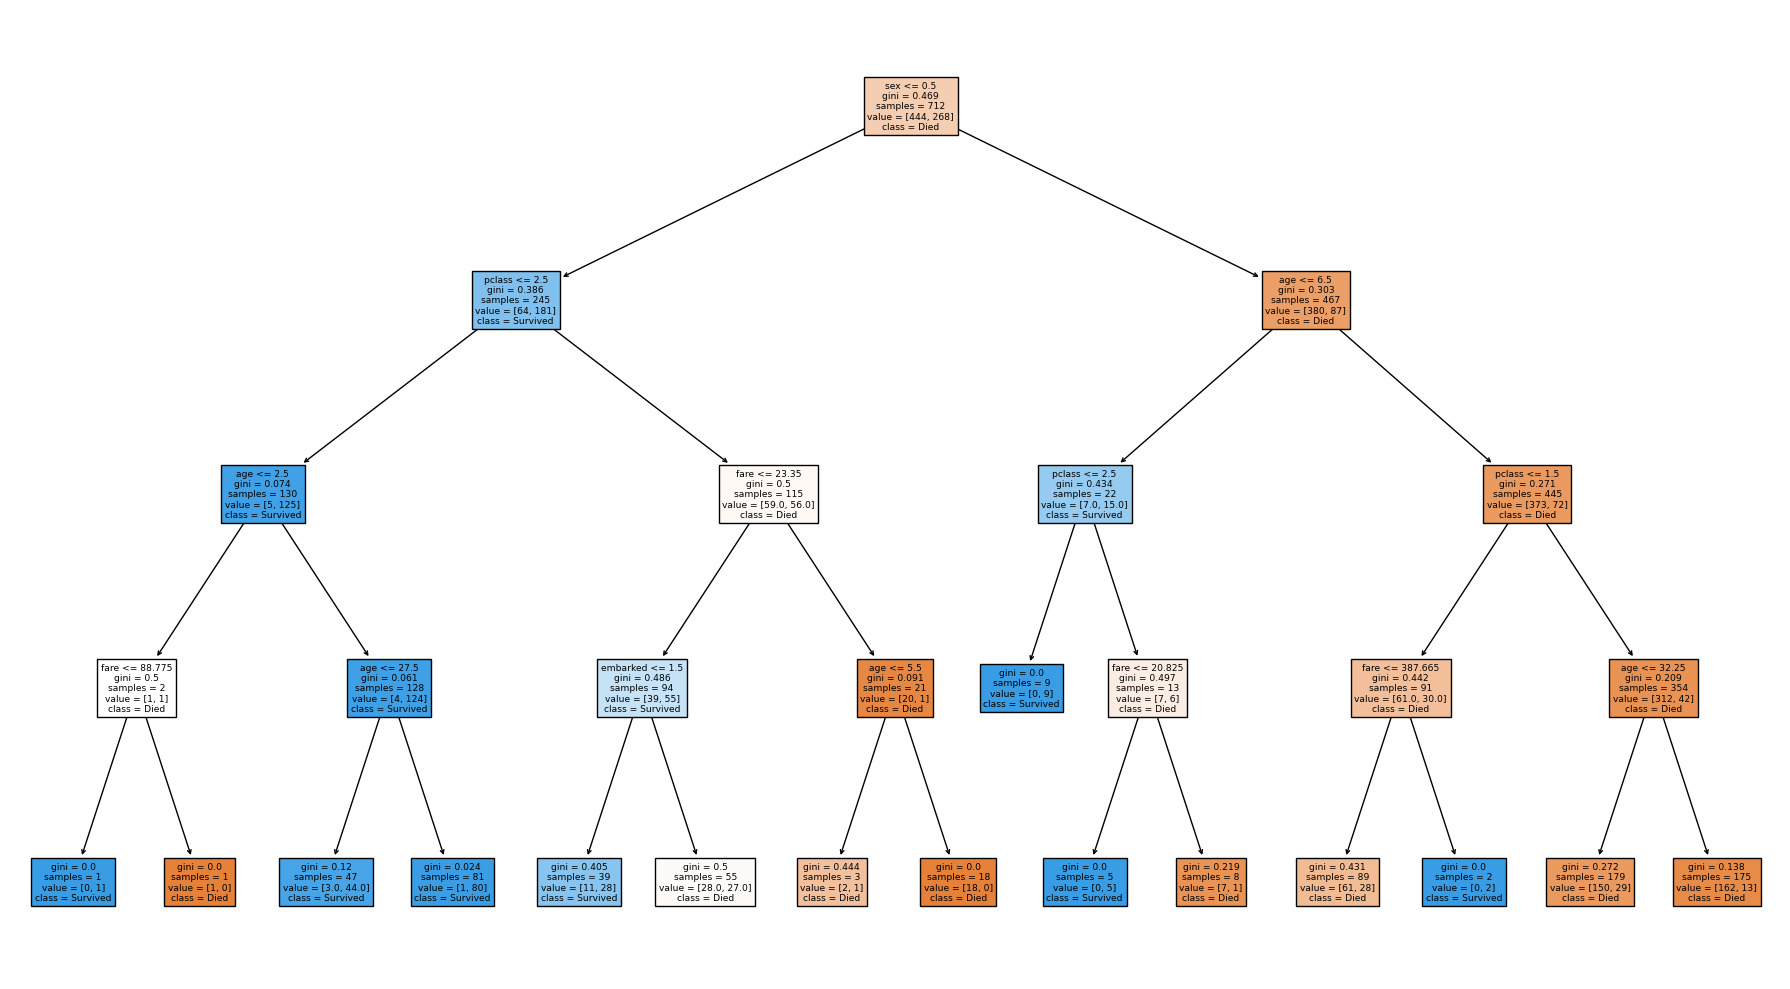

for depth=5, accuracy=0.7932960893854749
for depth=6, accuracy=0.7988826815642458
for depth=7, accuracy=0.8100558659217877
for depth=8, accuracy=0.7932960893854749
for depth=9, accuracy=0.7877094972067039
for depth=10, accuracy=0.8044692737430168


In [111]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth={depth}, accuracy={acc}")

    if depth==4:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()


for sample split=5, accuracy=0.7988826815642458
for sample split=10, accuracy=0.7988826815642458


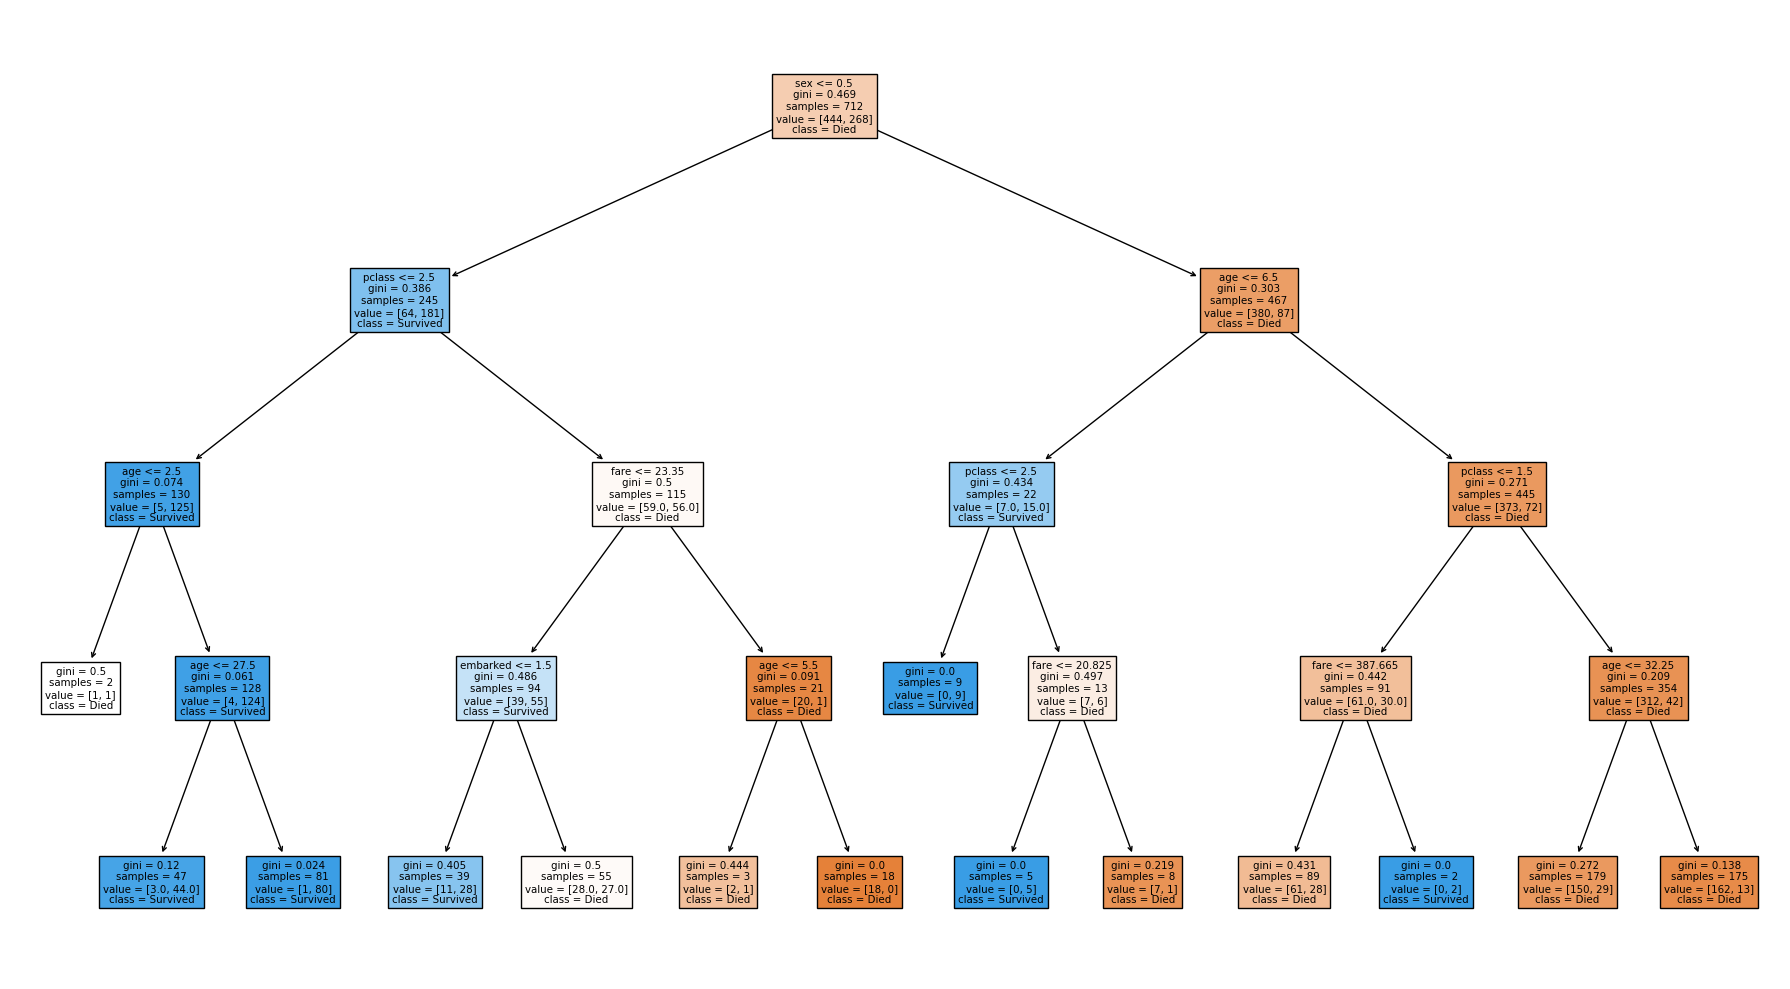

for sample split=15, accuracy=0.7988826815642458
for sample split=20, accuracy=0.7988826815642458
for sample split=25, accuracy=0.7932960893854749
for sample split=30, accuracy=0.7932960893854749


In [114]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for sample split={split}, accuracy={acc}")

    if split==10:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

# Decision Tree with post-pruning

In [120]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [123]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 5.67472478e-05 6.25888762e-05
 1.25893054e-04 1.83921883e-04 2.34082397e-04 2.34082397e-04
 2.80898876e-04 3.51123596e-04 3.70416101e-04 4.68164794e-04
 4.72846442e-04 5.58512386e-04 5.61797753e-04 5.61797753e-04
 6.67991230e-04 7.49063670e-04 8.19288390e-04 8.42696629e-04
 8.42696629e-04 8.77238365e-04 8.77808989e-04 9.14036026e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.88347898e-04
 9.93949870e-04 1.07400895e-03 1.13237360e-03 1.17041199e-03
 1.20642466e-03 1.22893258e-03 1.22893258e-03 1.26404494e-03
 1.28883014e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.40014729e-03 1.43570537e-03 1.49812734e-03 1.51229549e-03
 1.60434338e-03 1.67201712e-03 1.67576935e-03 1.71739909e-03
 1.72860847e-03 1.75561798e-03 1.86337660e-03 1.86751451e-03
 1.90081946e-03 2.10674157e-03 2.14653267e-03 2.34082397e-03
 2.41226470e-03 2.64273538e-03 2.72281067e-03 3.43770913e-03
 3.56327570e-03 5.47433606e-03 9.05540038e-03 1.39295081e-02
 1.59241633e-02 3.860535

In [130]:
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    trees.append((model, alpha))

In [138]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [141]:
best_acc

0.8268156424581006

In [144]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.001863376598217745, max_depth=4)

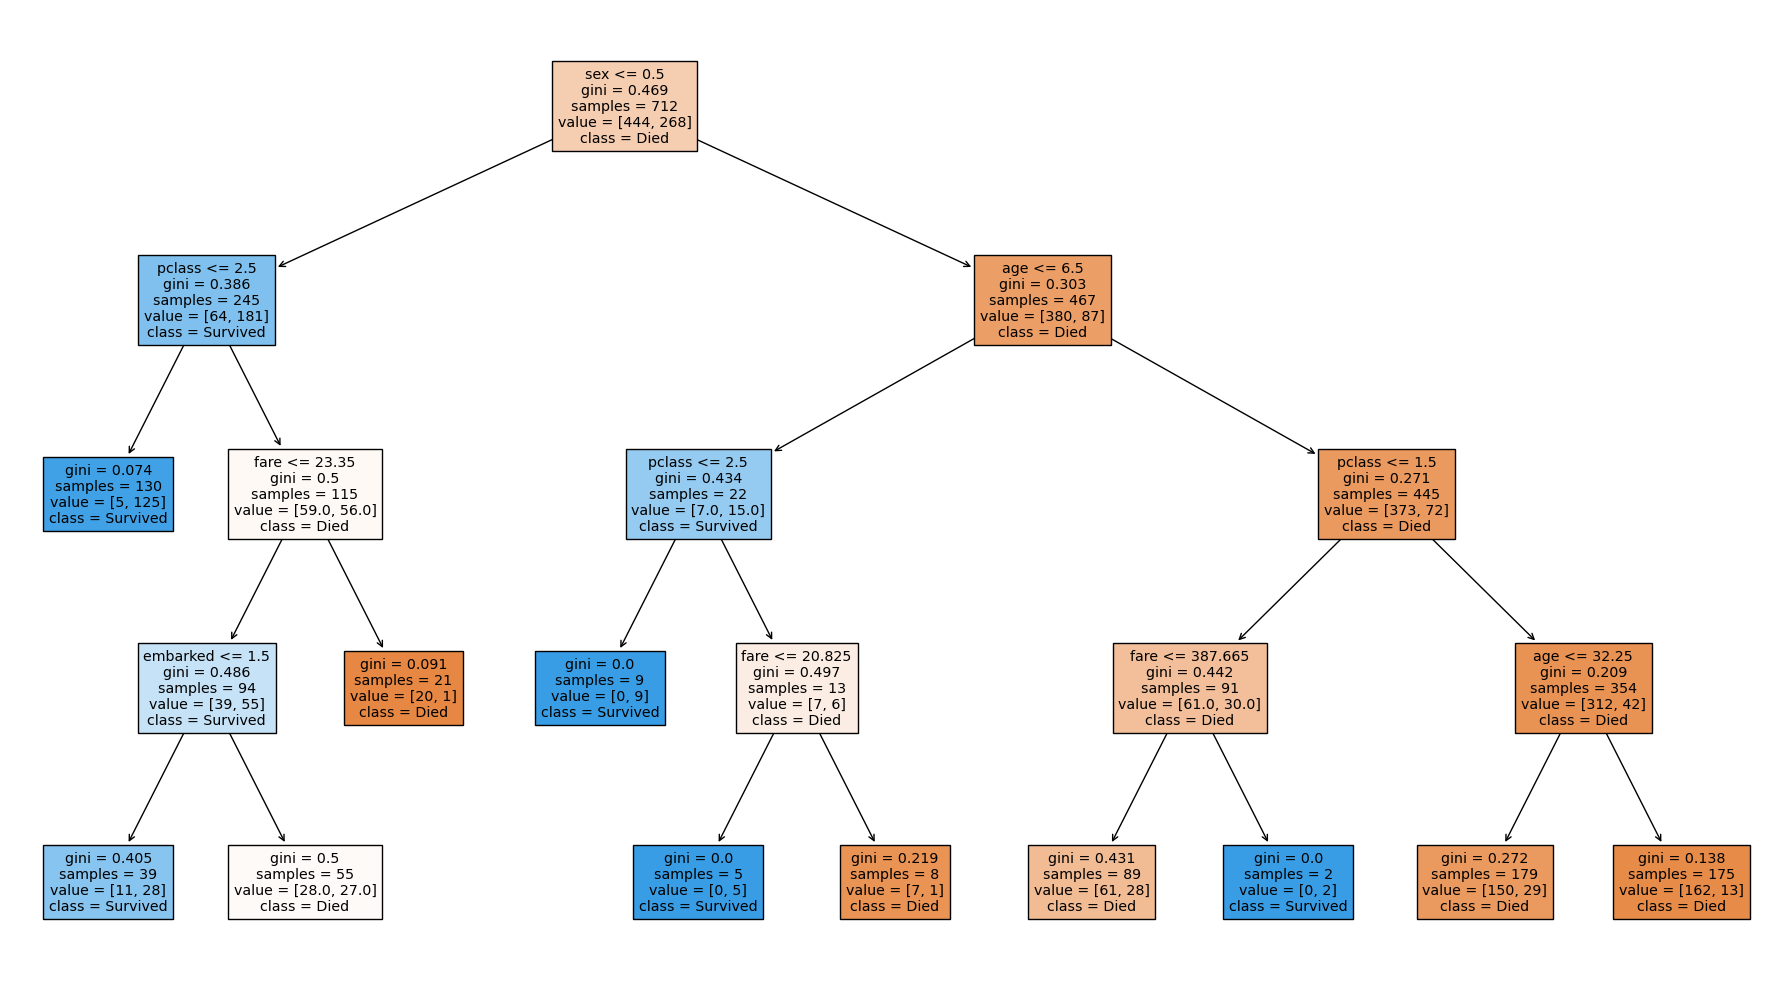

In [147]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)
        
plt.tight_layout()
plt.show()

In [150]:
print(best_model.score(X_test, y_test))

0.7988826815642458
